# Proyecto Final - Machine Learning
**Análisis y Clasificación de la Calidad de Aguas Superficiales mediante Ciencia de Datos y Aprendizaje Automático**

Autores: 
* Fanny Sandoval
* María José Espinal 


# Tabla de Contenidos <a id='table_of_contents'></a>

0. [Importar librerías](#imports)
1. [Auditoría inicial de los datos](#initial_eda)

   1.1. [Dimensiones del dataset](#size_data)
   
   1.2. [Tipos de datos](#data_type)

   1.3. [Duplicados](#duplicated)

   1.4. [Valores faltantes](#missing)

   1.5 [Variable objetivo](#obj_variable)

2. [Validación de la capa Silver](#capa_silver)


# 0. Importar librerías <a id='imports'></a>
[Back to top](#table_of_contents)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Auditoría inicial de los datos <a id='initial_eda'></a>
[Back to top](#table_of_contents)


Antes de realizar transformaciones o modelos de Machine Learning, se validará la estructura del dataset, tipos de datos, valores faltantes, duplicados y distribución de la variable objetivo. 
Esta etapa permite conocer la calidad de los datos y tomar decisiones de limpieza fundamentadas.

In [23]:

pd.set_option('display.max_columns', None)
file_path = r'C:\Users\maria\OneDrive\Desktop\VSC\Datos_de_calidad_del_agua_2020\Datos_de_calidad_del_agua_de_sitios_de_monitoreo_de_aguas_superficiales_2020.csv'
df = pd.read_csv(file_path, encoding='latin1')

display(df.head(19))


,CLAVE,SITIO,ORGANISMO_DE_CUENCA,ESTADO,MUNICIPIO,CUENCA,CUERPO DE AGUA,TIPO,SUBTIPO,LONGITUD,LATITUD,PERIODO,DBO_mg/L,CALIDAD_DBO,DQO_mg/L,CALIDAD_DQO,SST_mg/L,CALIDAD_SST,COLI_FEC_NMP_100mL,CALIDAD_COLI_FEC,E_COLI_NMP_100mL,CALIDAD_E_COLI,ENTEROC_NMP_100mL,CALIDAD_ENTEROC,OD_PORC,CALIDAD_OD_PORC,OD_PORC_SUP,CALIDAD_OD_PORC_SUP,OD_PORC_MED,CALIDAD_OD_PORC_MED,OD_PORC_FON,CALIDAD_OD_PORC_FON,TOX_D_48_UT,CALIDAD_TOX_D_48,TOX_V_15_UT,CALIDAD_TOX_V_15,TOX_D_48_SUP_UT,CALIDAD TOX_D_48_SUP,TOX_D_48_FON_UT,CALIDAD_TOX_D_48_FON,TOX_FIS_SUP_15_UT,CALIDAD_TOX_FIS_SUP_15,TOX_FIS_FON_15_UT,CALIDAD_TOX_FIS_FON_15,SEMAFORO,CONTAMINANTES,CUMPLE_CON_DBO,CUMPLE_CON_DQO,CUMPLE_CON_SST,CUMPLE_CON_CF,CUMPLE_CON_E_COLI,CUMPLE_CON_ENTEROC,CUMPLE_CON_OD,CUMPLE_CON_TOX,GRUPO
0,DLAGU8,PRESA EL SAUCILLO 100M AGUAS ARRIBA DE LA CORTINA,LERMA SANTIAGO PACIFICO,AGUASCALIENTES,RINCON DE ROMOS,RIO SAN PEDRO,PRESA EL SAUCILLO,LENTICO,PRESA,-102.33911,22.24730,2020.0,6,Buena calidad,54.08,Contaminada,13.75,Excelente,1162,Contaminada,98,Excelente,NaN,NaN,NaN,NaN,46.8,Aceptable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,<1,No Toxico,NaN,NaN,Rojo,"DQO,CF,",SI,NO,SI,NO,SI,ND,SI,SI,LENTICO
1,DLBAJ100,"LOS CABOS SEG 22, 2 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN JOSE DEL CABO,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.84290,22.90473,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,20,Excelente,NaN,NaN,92,Excelente,95.4,Excelente,92.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
2,DLBAJ101,"LOS CABOS SEG 22, 1 ISA10B",PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,OCEANO PACIFICO,COSTERO,OCEANO-MAR,-109.86442,22.89880,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,92,Excelente,95.4,Excelente,92.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
3,DLBAJ102,LOS CABOS 3,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.88604,22.89609,2020.0,NaN,NaN,NaN,NaN,13.9667,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,86.7,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
4,DLBAJ103,LOS CABOS 1,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.89657,22.87694,2020.0,NaN,NaN,NaN,NaN,<10,Excelente,NaN,NaN,NaN,NaN,30,Excelente,NaN,NaN,96.2,Excelente,95.9,Excelente,95.5,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
5,DLBAJ104,BAHIA CABO SAN LUCAS,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.90250,22.88000,2020.0,NaN,NaN,NaN,NaN,22.0667,Excelente,NaN,NaN,NaN,NaN,<3,Excelente,NaN,NaN,90.1,Excelente,95.2,Excelente,94.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
6,DLBAJ105,LOS CABOS 2,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LOS CABOS,SAN LUCAS,BAHIA SAN LUCAS,COSTERO,BAHIA,-109.90540,22.88310,2020.0,NaN,NaN,NaN,NaN,13.9667,Excelente,NaN,NaN,NaN,NaN,90,Excelente,NaN,NaN,81.9,Excelente,82.4,Excelente,79.2,Excelente,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Verde,NaN,ND,ND,SI,ND,ND,SI,SI,SI,COSTERO
7,DLBAJ106W2,LAGUNA TODOS SANTOS - CENTRO DE LA LAGUNA,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LA PAZ,TODOS SANTOS,TODOS SANTOS,COSTERO,LAGUNA,-110.23902,23.43930,2020.0,NaN,NaN,NaN,NaN,57.85,Buena calidad,NaN,NaN,NaN,NaN,402,Contaminada,NaN,NaN,NaN,NaN,NaN,NaN,146,Contaminada,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1,No Toxico,NaN,NaN,Rojo,"ENT_FEC,OD%F,",ND,ND,SI,ND,ND,NO,NO,SI,COSTERO
8,DLBAJ109,MANANTIAL SAN REGIS,PENINSULA DE BAJA CALIFORNIA,BAJA CALIFORNIA SUR,LA PAZ,TODOS SANTOS,TODOS SANTOS,LOTICO,ARROYO,-110.22379,23.45805,2020.0,<2,Excelente,<10,Excelente,33.9,Buena calidad,3873,Contaminada,512,Buena calidad

## 1.1. Dimensiones del dataset <a id='size_data'></a>
[Back to top](#table_of_contents)

In [24]:
print("Dimensiones del dataset:")
print(df.shape)

print("\nNúmero de filas:")
print(df.shape[0])

print("\nNúmero de columnas:")
print(df.shape[1])

Dimensiones del dataset:
(4141, 55)

Número de filas:
4141

Número de columnas:
55


## 1.2. Tipos de datos <a id='data_type'></a>
[Back to top](#table_of_contents)

In [25]:
df.dtypes.value_counts()

str        48
float64     7
Name: count, dtype: int64

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4141 entries, 0 to 4140
Data columns (total 55 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CLAVE                   3493 non-null   str    
 1   SITIO                   3493 non-null   str    
 2   ORGANISMO_DE_CUENCA     3493 non-null   str    
 3   ESTADO                  3493 non-null   str    
 4   MUNICIPIO               3493 non-null   str    
 5   CUENCA                  3492 non-null   str    
 6   CUERPO DE AGUA          3479 non-null   str    
 7   TIPO                    3493 non-null   str    
 8   SUBTIPO                 3479 non-null   str    
 9   LONGITUD                3493 non-null   float64
 10  LATITUD                 3493 non-null   float64
 11  PERIODO                 3493 non-null   float64
 12  DBO_mg/L                2581 non-null   str    
 13  CALIDAD_DBO             2581 non-null   str    
 14  DQO_mg/L                2581 non-null   str    
 15

## 1.3. Duplicados <a id='duplicated'></a>
[Back to top](#table_of_contents)

In [27]:
duplicados = df.duplicated().sum()

print(f"Número de registros duplicados: {duplicados}")

Número de registros duplicados: 647


## 1.4. Valores faltantes <a id='missing'></a>
[Back to top](#table_of_contents)

In [28]:
faltantes = pd.DataFrame({
    "Valores faltantes": df.isnull().sum(),
    "Porcentaje": df.isnull().mean() * 100
})

faltantes = faltantes.sort_values(
    "Porcentaje",
    ascending=False
)

display(faltantes)

,Valores faltantes,Porcentaje
TOX_FIS_FON_15_UT,4141,100.000000
CALIDAD_TOX_FIS_FON_15,4141,100.000000
TOX_D_48_FON_UT,4141,100.000000
CALIDAD_TOX_D_48_FON,4141,100.000000
OD_PORC_MED,3654,88.239556
CALIDAD_OD_PORC_MED,3654,88.239556
CALIDAD TOX_D_48_SUP,3379,81.598648
TOX_D_48_SUP_UT,3379,81.598648
ENTEROC_NMP_100mL,3237,78.169524
CALIDAD_ENTEROC,3237,78.169524


## 1.5 Variable objetivo <a id='obj_variable'></a>
[Back to top](#table_of_contents)

In [29]:
print("Distribución de SEMAFORO:")

display(
    df["SEMAFORO"].value_counts()
)

Distribución de SEMAFORO:


SEMAFORO
Verde       1267
Amarillo    1135
Rojo        1091
Name: count, dtype: int64

In [30]:
display(
    df["SEMAFORO"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

SEMAFORO
Verde       36.27
Amarillo    32.49
Rojo        31.23
Name: proportion, dtype: float64

## **Primera Parte**


### Limpieza de base de datos


1.    Se realiza la limpieza de la daset, identificando y eliminando las variables que presenten el 100% de los valores nulos, ya que, estas no aportan relevancia al analisis por falta de información.
2.   Correccion de tipo de variable, se identifican variables como : DBO, DQO, sólidos suspendidos, bacterias y oxígeno disuelto cualitativas por ND: valores no detectados, presentadas como cuantitativas por lo que se procede a la transformación.
3. Con respecto a los valores no detectados, estos fueron reemplazados por valores faltantes, para un manejo mas adecuado del dataset.
4.  Ahora bien, ya una vez reemplazadas las variables estas fueron convertidas a float64.
5. Y como ultimo, se verifica la informacion de la dataframe con los cambios realizados.


In [31]:

# 1. Eliminar columnas con 100% de valores nulos
# Identificar columnas con todos los valores nulos
columns_to_drop_100_null = df.columns[df.isnull().all()].tolist()
print(f"Columnas con el 100% de valores nulos a eliminar: {columns_to_drop_100_null}")
df = df.drop(columns=columns_to_drop_100_null)

# 2. Convertir columnas numéricas que son 'object' a tipo numérico, manejando 'ND'
# Lista de columnas identificadas como numéricas pero que son 'object' en df.info()
numeric_object_cols = [
    'DBO_mg/L', 'DQO_mg/L', 'SST_mg/L', 'COLI_FEC_NMP_100mL',
    'E_COLI_NMP_100mL', 'ENTEROC_NMP_100mL', 'OD_PORC', 'OD_PORC_SUP',
    'OD_PORC_MED', 'OD_PORC_FON', 'TOX_D_48_UT', 'TOX_V_15_UT',
    'TOX_D_48_SUP_UT', 'TOX_FIS_SUP_15_UT'
]

for col in numeric_object_cols:
    if col in df.columns:
        # Reemplazar 'ND' por NaN y convertir a tipo numérico
        df[col] = df[col].replace('ND', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"Columna '{col}' convertida a tipo numérico (float).")

print("\nPrimeros pasos de limpieza completados.")
print("df.info() después de estos cambios:")
df.info()

Columnas con el 100% de valores nulos a eliminar: ['TOX_D_48_FON_UT', 'CALIDAD_TOX_D_48_FON', 'TOX_FIS_FON_15_UT', 'CALIDAD_TOX_FIS_FON_15']
Columna 'DBO_mg/L' convertida a tipo numérico (float).
Columna 'DQO_mg/L' convertida a tipo numérico (float).
Columna 'SST_mg/L' convertida a tipo numérico (float).
Columna 'COLI_FEC_NMP_100mL' convertida a tipo numérico (float).
Columna 'E_COLI_NMP_100mL' convertida a tipo numérico (float).
Columna 'ENTEROC_NMP_100mL' convertida a tipo numérico (float).
Columna 'OD_PORC' convertida a tipo numérico (float).
Columna 'OD_PORC_SUP' convertida a tipo numérico (float).
Columna 'OD_PORC_MED' convertida a tipo numérico (float).
Columna 'OD_PORC_FON' convertida a tipo numérico (float).
Columna 'TOX_D_48_UT' convertida a tipo numérico (float).
Columna 'TOX_V_15_UT' convertida a tipo numérico (float).
Columna 'TOX_D_48_SUP_UT' convertida a tipo numérico (float).
Columna 'TOX_FIS_SUP_15_UT' convertida a tipo numérico (float).

Primeros pasos de limpieza comp

## **Segunda Parte**

### Análisis Exploratorio

Antes de aplicar PCA se va a realizar un analisis exploratorio.

In [32]:
# Variables numéricas que entrarán al PCA

columnas_pca = [
    col for col in numeric_object_cols
    if col in df.columns
]

print("Variables seleccionadas:")
print(columnas_pca)

Variables seleccionadas:
['DBO_mg/L', 'DQO_mg/L', 'SST_mg/L', 'COLI_FEC_NMP_100mL', 'E_COLI_NMP_100mL', 'ENTEROC_NMP_100mL', 'OD_PORC', 'OD_PORC_SUP', 'OD_PORC_MED', 'OD_PORC_FON', 'TOX_D_48_UT', 'TOX_V_15_UT', 'TOX_D_48_SUP_UT', 'TOX_FIS_SUP_15_UT']


### Medidas de Centralidad y Dispersión

Se realizaran los calculos respectivos para conocer la distribución de cada variable.

- Media
- Mediana
- Desviación estándar
- Mínimo
- Máximo

In [33]:
resumen = df[columnas_pca].describe().T[
    ['mean', '50%', 'std', 'min', 'max']
]

resumen.columns = [
    'Media',
    'Mediana',
    'Desv. Estándar',
    'Mínimo',
    'Máximo'
]

display(resumen)

,Media,Mediana,Desv. Estándar,Mínimo,Máximo
DBO_mg/L,30.313933,9.0000,8.770966e+01,2.000,1.500000e+03
DQO_mg/L,79.353824,36.9600,1.661786e+02,10.000,2.871250e+03
SST_mg/L,133.229158,36.0000,5.072354e+02,10.000,9.430000e+03
COLI_FEC_NMP_100mL,99906.258391,2400.0000,1.194203e+06,3.000,2.419600e+07
E_COLI_NMP_100mL,92399.104195,930.0000,1.134086e+06,3.000,2.419600e+07
ENTEROC_NMP_100mL,2229.531136,74.0000,5.965510e+03,3.100,2.419600e+04
OD_PORC,70.546532,70.6000,2.875590e+01,10.140,2.261000e+02
OD_PORC_SUP,82.128242,84.4500,2.784254e+01,13.900,2.890000e+02
OD_PORC_MED,73.413953,73.1000,2.449817e+01,19.100,1.330000e+02
OD_PORC_FON,69.054116,68.8000,2.639108e+01,12.100,1.460000e+02


### Explicación

Interpretación de las Medidas Estadísticas

Media (Promedio)
La media representa el valor promedio de concentración de un contaminante dentro de un grupo específico de sitios clasificados según el semáforo de calidad del agua (Verde, Amarillo o Rojo). Este indicador permite identificar la tendencia general de contaminación en cada categoría.

Relación con la calidad del agua:

Una media elevada indica mayores concentraciones del contaminante, lo que sugiere un deterioro en la calidad del agua.
Una media baja refleja menores niveles de contaminación y, por tanto, una mejor calidad del recurso hídrico.

Mediana
La mediana corresponde al valor central de los datos ordenados y representa el punto donde el 50% de las observaciones se encuentran por encima y el otro 50% por debajo.

Relación con la calidad del agua:

Cuando la mediana es similar a la media, los datos presentan una distribución relativamente uniforme.
Si existe una diferencia significativa entre la media y la mediana, puede indicar la presencia de valores atípicos (outliers) que afectan el promedio.
Una mediana alta también es indicativa de mayores niveles de contaminación y, por ende, de una menor calidad del agua.

Desviación Estándar
La desviación estándar mide el grado de dispersión o variabilidad de los datos respecto a la media. Este estadístico permite evaluar qué tan consistentes son las concentraciones de un contaminante dentro de una misma categoría.

Relación con la calidad del agua:

Una desviación estándar alta indica una gran variabilidad en las concentraciones, lo que sugiere que algunos sitios presentan niveles muy bajos de contaminación mientras que otros registran niveles considerablemente altos. Esta situación puede reflejar una calidad del agua inestable o heterogénea.
Una desviación estándar baja indica que los valores se encuentran cercanos a la media, mostrando una mayor uniformidad en las concentraciones observadas.
Si esta uniformidad ocurre con valores bajos de contaminación, la calidad del agua puede considerarse consistentemente buena.
Si ocurre con valores altos, evidencia una contaminación persistente y generalizada en los sitios evaluados.

## Tercera Parte

### Transformación

Se aplica una transformación logarítmica para reducir la influencia de valores extremos y mejorar la distribución de los datos.

In [34]:
df_pca_log = np.log10(
    df[columnas_pca] + 1
)

display(df_pca_log.head())

,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,ENTEROC_NMP_100mL,OD_PORC,OD_PORC_SUP,OD_PORC_MED,OD_PORC_FON,TOX_D_48_UT,TOX_V_15_UT,TOX_D_48_SUP_UT,TOX_FIS_SUP_15_UT
0,0.845098,1.740994,1.168792,3.06558,1.995635,NaN,NaN,1.679428,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,1.322219,NaN,1.968483,1.984077,1.969416,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.968483,1.984077,1.969416,NaN,NaN,NaN,NaN
3,NaN,NaN,1.175126,NaN,NaN,NaN,NaN,NaN,NaN,1.943000,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,1.491362,NaN,1.987666,1.986324,1.984527,NaN,NaN,NaN,NaN


##Cuarta Parte

### Imputación de Datos Faltantes

Los valores faltantes se reemplazan utilizando la media de cada variable.

In [35]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(
    strategy='mean'
)

df_pca_imputed = imputer.fit_transform(
    df_pca_log
)

df_pca_imputed = pd.DataFrame(
    df_pca_imputed,
    columns=columnas_pca
)

display(df_pca_imputed.head())

,DBO_mg/L,DQO_mg/L,SST_mg/L,COLI_FEC_NMP_100mL,E_COLI_NMP_100mL,ENTEROC_NMP_100mL,OD_PORC,OD_PORC_SUP,OD_PORC_MED,OD_PORC_FON,TOX_D_48_UT,TOX_V_15_UT,TOX_D_48_SUP_UT,TOX_FIS_SUP_15_UT
0,0.845098,1.740994,1.168792,3.06558,1.995635,2.086777,1.810529,1.679428,1.842695,1.806879,0.465319,0.846254,0.447438,0.608899
1,1.128679,1.643599,1.681657,3.39865,2.988021,1.322219,1.810529,1.968483,1.984077,1.969416,0.465319,0.846254,0.447438,0.608899
2,1.128679,1.643599,1.681657,3.39865,2.988021,2.086777,1.810529,1.968483,1.984077,1.969416,0.465319,0.846254,0.447438,0.608899
3,1.128679,1.643599,1.175126,3.39865,2.988021,2.086777,1.810529,1.892925,1.842695,1.943000,0.465319,0.846254,0.447438,0.608899
4,1.128679,1.643599,1.681657,3.39865,2.988021,1.491362,1.810529,1.987666,1.986324,1.984527,0.465319,0.846254,0.447438,0.608899


In [36]:
(df_pca_log.isnull().sum() / len(df_pca_log)) * 100

DBO_mg/L              67.230138
DQO_mg/L              51.171215
SST_mg/L              36.995895
COLI_FEC_NMP_100mL    40.280126
E_COLI_NMP_100mL      46.462207
ENTEROC_NMP_100mL     89.374547
OD_PORC               59.261048
OD_PORC_SUP           61.265395
OD_PORC_MED           88.577638
OD_PORC_FON           78.000483
TOX_D_48_UT           97.899058
TOX_V_15_UT           96.425984
TOX_D_48_SUP_UT       99.420430
TOX_FIS_SUP_15_UT     99.589471
dtype: float64

### Estandarización de Variables

Para poder realizar PCA es necesario que todas las variables esten en la misma escala.

Por ello cada variable se transforma para tener:

- Media = 0
- Desviación estándar = 1

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

datos_escalados = scaler.fit_transform(
    df_pca_imputed
)

print("Datos estandarizados correctamente.")

Datos estandarizados correctamente.


## Quinta Parte

### Aplicación del PCA



In [38]:
from sklearn.decomposition import PCA

pca = PCA()

componentes_principales = pca.fit_transform(
    datos_escalados
)

print("PCA ejecutado correctamente.")

PCA ejecutado correctamente.


In [39]:
var_explicada = pca.explained_variance_ratio_

var_acumulada = (
    var_explicada.cumsum()
)

for i, var in enumerate(var_explicada):
    print(
        f"CP{i+1}: "
        f"{var*100:.2f}% "
        f"(Acumulado: "
        f"{var_acumulada[i]*100:.2f}%)"
    )

CP1: 18.36% (Acumulado: 18.36%)
CP2: 13.14% (Acumulado: 31.50%)
CP3: 9.00% (Acumulado: 40.50%)
CP4: 7.65% (Acumulado: 48.15%)
CP5: 7.59% (Acumulado: 55.74%)
CP6: 7.17% (Acumulado: 62.91%)
CP7: 6.69% (Acumulado: 69.61%)
CP8: 6.59% (Acumulado: 76.20%)
CP9: 6.34% (Acumulado: 82.54%)
CP10: 5.56% (Acumulado: 88.09%)
CP11: 4.86% (Acumulado: 92.96%)
CP12: 2.85% (Acumulado: 95.81%)
CP13: 2.56% (Acumulado: 98.37%)
CP14: 1.63% (Acumulado: 100.00%)


### Gráfico de Varianza Acumulada

El gráfico permite identificar cuántos componentes son necesarios para conservar aproximadamente el 80% de la información original.

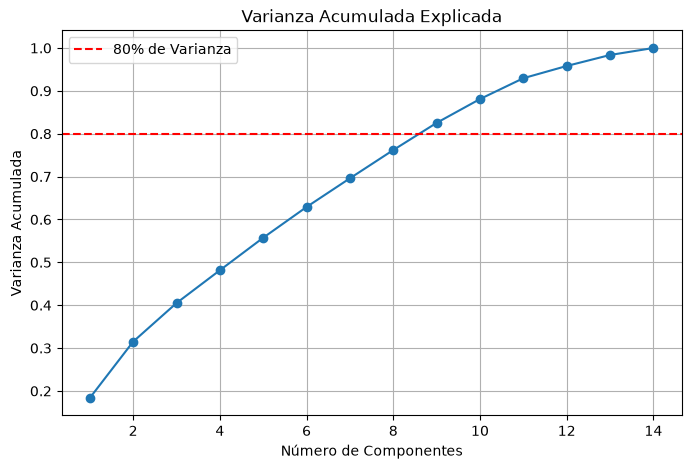

In [40]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(var_acumulada)+1),
    var_acumulada,
    marker='o'
)

plt.axhline(
    y=0.80,
    color='red',
    linestyle='--',
    label='80% de Varianza'
)

plt.title(
    'Varianza Acumulada Explicada'
)

plt.xlabel(
    'Número de Componentes'
)

plt.ylabel(
    'Varianza Acumulada'
)

plt.legend()
plt.grid(True)
plt.show()

## Sexta Parte

### Recreación de graficos

Para visualizar datos de una manera mejor visualmente

### Graficos 1 - Grafica de semaforo rojo por estado

Michoacán destaca como el estado con mayor número absoluto de sitios con mala calidad del agua. Esto sugiere una presencia significativa de cuerpos de agua afectados por contaminación.

Veracruz y Jalisco también presentan una gran cantidad de sitios rojos, indicando que la problemática no está concentrada en una sola región del país.

Por lo tanto, los estados de Michoacán, Veracruz y Jalisco concentran la mayor cantidad de cuerpos de agua con mala calidad, convirtiéndose en zonas prioritarias para programas de saneamiento y control de la contaminación.

Estados con más sitios en semáforo rojo:
                             ESTADO  Cantidad_Sitios_Rojos
15              MICHOACAN DE OCAMPO                    125
29  VERACRUZ DE IGNACIO DE LA LLAVE                    108
13                          JALISCO                     93
10                       GUANAJUATO                     89
14                           MEXICO                     73
20                           PUEBLA                     63
11                         GUERRERO                     50
27                       TAMAULIPAS                     47
19                           OAXACA                     44
4                           CHIAPAS                     42


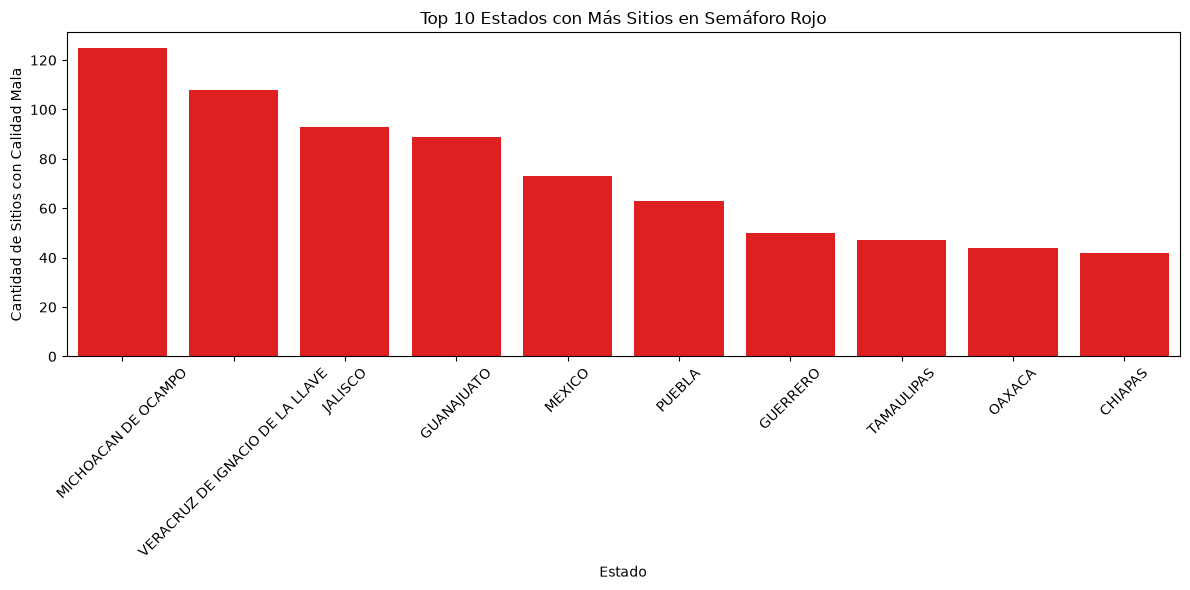

In [41]:

# Filtrar únicamente sitios con semáforo rojo
df_rojo = df[df['SEMAFORO'] == 'Rojo']

# Contar sitios rojos por estado
estados_rojos = (
    df_rojo.groupby('ESTADO')
           .size()
           .reset_index(name='Cantidad_Sitios_Rojos')
           .sort_values('Cantidad_Sitios_Rojos', ascending=False)
)

# Mostrar tabla
print("Estados con más sitios en semáforo rojo:")
print(estados_rojos.head(10))

# Gráfico
plt.figure(figsize=(12,6))

sns.barplot(
    data=estados_rojos.head(10),
    x='ESTADO',
    y='Cantidad_Sitios_Rojos',
    color='red'
)

plt.title('Top 10 Estados con Más Sitios en Semáforo Rojo')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Sitios con Calidad Mala')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

###Grafico 2 - Recreacion de datos de semaforo verde por estado

Oaxaca y Chiapas destacan por tener la mayor cantidad de sitios con buena calidad del agua. Esto sugiere que una parte importante de sus cuerpos de agua mantiene condiciones ambientales favorables.

Oaxaca y Chiapas sobresalen por presentar la mayor cantidad de sitios con buena calidad del agua, lo que refleja condiciones ambientales relativamente favorables en comparación con otros estados.

Estados con más sitios en semáforo verde:
                             ESTADO  Cantidad_Sitios_Verdes
18                           OAXACA                     117
4                           CHIAPAS                     116
21                     QUINTANA ROO                     108
23                          SINALOA                      94
10                         GUERRERO                      79
28  VERACRUZ DE IGNACIO DE LA LLAVE                      70
2               BAJA CALIFORNIA SUR                      70
24                           SONORA                      68
12                          JALISCO                      67
26                       TAMAULIPAS                      66


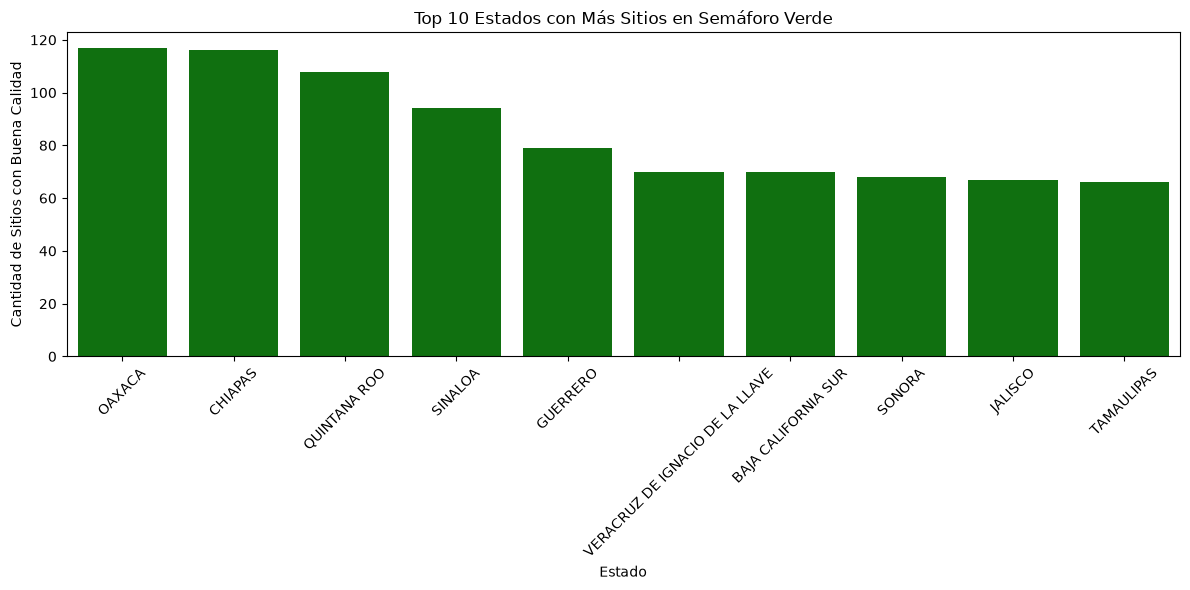

In [42]:
# Filtrar únicamente sitios con semáforo verde
df_verde = df[df['SEMAFORO'] == 'Verde']

# Contar sitios verdes por estado
estados_verdes = (
    df_verde.groupby('ESTADO')
            .size()
            .reset_index(name='Cantidad_Sitios_Verdes')
            .sort_values('Cantidad_Sitios_Verdes', ascending=False)
)

# Mostrar tabla
print("Estados con más sitios en semáforo verde:")
print(estados_verdes.head(10))

# Gráfico
plt.figure(figsize=(12,6))

sns.barplot(
    data=estados_verdes.head(10),
    x='ESTADO',
    y='Cantidad_Sitios_Verdes',
    color='green' # Cambiado el color a verde
)

plt.title('Top 10 Estados con Más Sitios en Semáforo Verde')
plt.xlabel('Estado')
plt.ylabel('Cantidad de Sitios con Buena Calidad')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Grafico 3 - Comparación de semaforos

**DBO**

Representa la cantidad de oxígeno que necesitan los microorganismos para degradar materia orgánica.
El incremento de 7 a 46 mg/L (amarilo a rojo) indica una fuerte carga de contaminación orgánica.

**DQO**

Mide la cantidad total de materia susceptible de oxidarse.
El salto de 22 a 144.5 mg/L (verde a rojo) evidencia una gran acumulación de contaminantes químicos y orgánicos.

**SST**

Los sólidos suspendidos pasan de 33 a 227 mg/L (verde a rojo).
Esto significa que los cuerpos de agua más contaminados contienen grandes cantidades de partículas suspendidas, sedimentos y residuos.

**Hallazgo clave**

El contaminante que más diferencia a los sitios rojos de los verdes son los SST.

Los sólidos suspendidos totales (SST) constituyen el indicador que presenta el mayor incremento entre los sitios de buena y mala calidad, sugiriendo que la acumulación de partículas suspendidas es uno de los factores más asociados al deterioro de la calidad del agua.

Promedios de contaminantes por semáforo:
          DBO_mg/L  DQO_mg/L  SST_mg/L
SEMAFORO                              
Amarillo      7.37     23.19    125.97
Rojo         45.72    144.59    227.69
Verde         6.44     22.33     32.42


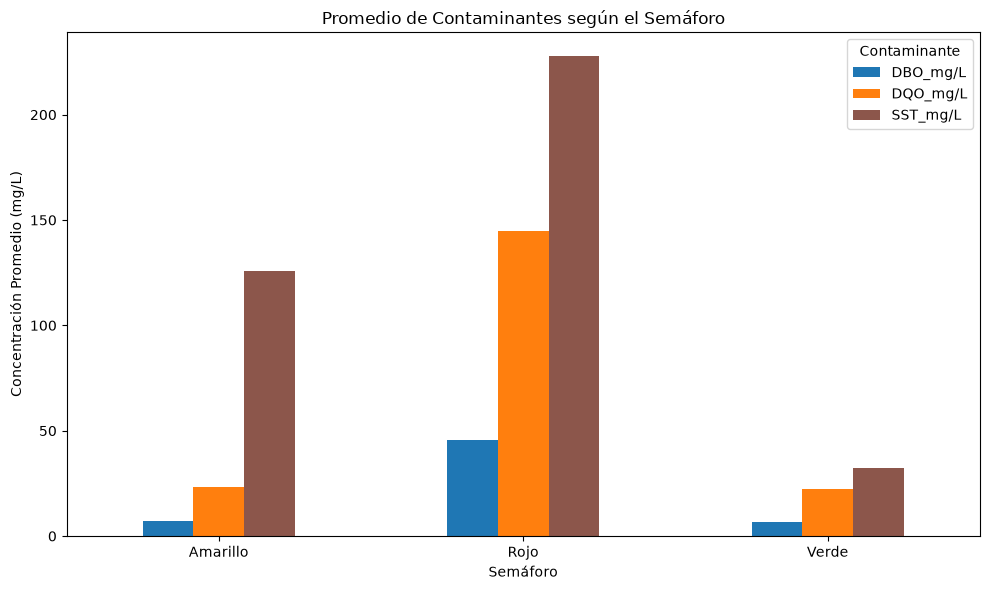

In [43]:
variables = ['DBO_mg/L', 'DQO_mg/L', 'SST_mg/L']

# Calcular promedios
promedios = (
    df.groupby('SEMAFORO')[variables]
      .mean()
      .round(2)
)

print("Promedios de contaminantes por semáforo:")
print(promedios)


promedios.plot(
    kind='bar',
    figsize=(10,6),
    color=[
        '#1f77b4',  # DBO - azul
        '#ff7f0e',  # DQO - naranja
        '#8c564b'   # SST - marrón
    ]
)

plt.title('Promedio de Contaminantes según el Semáforo')
plt.xlabel('Semáforo')
plt.ylabel('Concentración Promedio (mg/L)')
plt.xticks(rotation=0)

plt.legend(title='Contaminante')

plt.tight_layout()
plt.show()

### Grafico 3


El análisis evidencia importantes diferencias regionales en la calidad del agua superficial en México. Mientras estados como Oaxaca y Chiapas presentan una alta proporción de sitios con buena calidad, entidades como Michoacán, Veracruz y Jalisco concentran mayores niveles de contaminación. Además, el incremento de los sólidos suspendidos totales y de la demanda química de oxígeno muestra una fuerte relación con el deterioro de la calidad del agua, convirtiéndolos en indicadores clave para la evaluación ambiental.


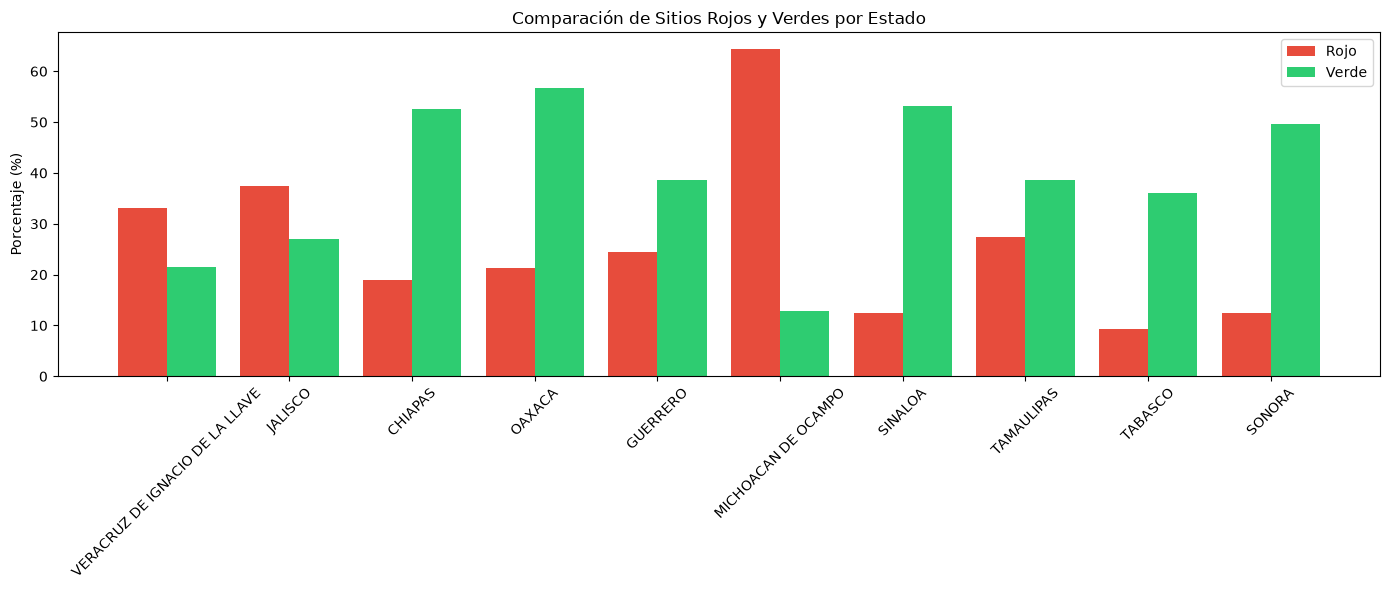

In [44]:
# ==========================================
# COMPARACIÓN ROJO VS VERDE
# ==========================================

# Calcular sitios totales por estado
total_estado = df.groupby('ESTADO').size().reset_index(name='Total_Sitios')

# Calcular sitios rojos por estado
rojos_estado = df[df['SEMAFORO'] == 'Rojo'].groupby('ESTADO').size().reset_index(name='Sitios_Rojos')

# Calcular sitios verdes por estado
verdes_estado = df[df['SEMAFORO'] == 'Verde'].groupby('ESTADO').size().reset_index(name='Sitios_Verdes')

comparacion = total_estado.copy()

comparacion = comparacion.merge(
    rojos_estado,
    on='ESTADO',
    how='left'
)

comparacion = comparacion.merge(
    verdes_estado,
    on='ESTADO',
    how='left'
)

comparacion = comparacion.fillna(0)

comparacion['Porcentaje_Rojo'] = (
    comparacion['Sitios_Rojos']
    / comparacion['Total_Sitios']
) * 100

comparacion['Porcentaje_Verde'] = (
    comparacion['Sitios_Verdes']
    / comparacion['Total_Sitios']
) * 100

# Top de los 10 estados con más sitios monitoreados
comparacion = comparacion.sort_values(
    'Total_Sitios',
    ascending=False
).head(10)

plt.figure(figsize=(14,6))

x = range(len(comparacion))
ancho = 0.4

plt.bar(
    [i - ancho/2 for i in x],
    comparacion['Porcentaje_Rojo'],
    width=ancho,
    label='Rojo',
    color='#e74c3c'
)

plt.bar(
    [i + ancho/2 for i in x],
    comparacion['Porcentaje_Verde'],
    width=ancho,
    label='Verde',
    color='#2ecc71'
)

plt.xticks(x, comparacion['ESTADO'], rotation=45)

plt.ylabel('Porcentaje (%)')
plt.title('Comparación de Sitios Rojos y Verdes por Estado')
plt.legend()

plt.tight_layout()
plt.show()

### Grafico 4

El análisis de la distribución de los semáforos por tipo de cuerpo de agua muestra que los cuerpos lóticos (ríos y corrientes) concentran la mayor cantidad de sitios monitoreados y también la mayor cantidad de sitios clasificados en semáforo rojo y amarillo. Esto sugiere que los ríos son los ecosistemas acuáticos donde se registran más casos de deterioro en la calidad del agua.

Por otro lado, los cuerpos costeros presentan la mayor cantidad de sitios clasificados en semáforo verde, lo que indica que una gran parte de estos ecosistemas mantiene condiciones favorables de calidad del agua. Los sistemas lénticos (lagos y lagunas) presentan una distribución más equilibrada entre sitios verdes y rojos, reflejando una situación intermedia.

Sin embargo, debido a que cada grupo posee una cantidad diferente de sitios monitoreados, este gráfico permite identificar dónde se concentran más casos de contaminación, pero no necesariamente cuál grupo tiene la peor calidad relativa. Para ello, es más apropiado analizar los porcentajes de cada categoría dentro de cada tipo de cuerpo de agua.

SEMAFORO  Amarillo  Rojo  Verde
GRUPO                          
COSTERO         81   168    739
LENTICO        198   264    271
LOTICO         856   659    257


<Figure size 1000x600 with 0 Axes>

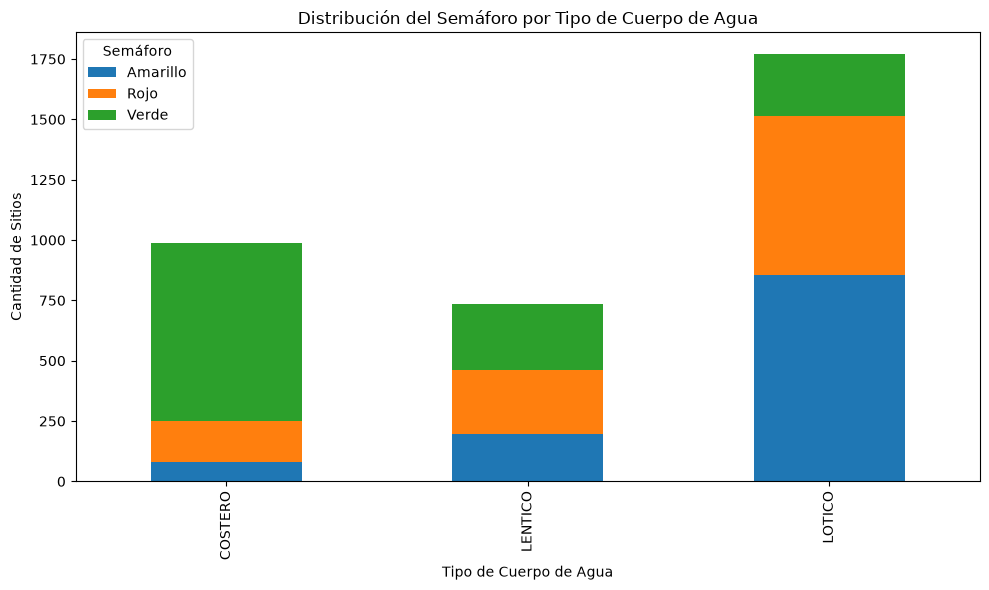

In [45]:
tabla = pd.crosstab(
    df['GRUPO'],
    df['SEMAFORO']
)

print(tabla)

plt.figure(figsize=(10,6))

tabla.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Distribución del Semáforo por Tipo de Cuerpo de Agua')
plt.xlabel('Tipo de Cuerpo de Agua')
plt.ylabel('Cantidad de Sitios')
plt.legend(title='Semáforo')

plt.tight_layout()
plt.show()

Este gráfico presenta la distribución porcentual de los sitios clasificados en semáforo Verde, Amarillo y Rojo para cada tipo de cuerpo de agua:

Costero
Léntico (lagos y lagunas)
Lótico (ríos y corrientes)

Al utilizar porcentajes, se elimina el efecto de que algunos grupos tengan más sitios monitoreados que otros, permitiendo una comparación más justa.

-------------------
El análisis porcentual revela diferencias significativas en la calidad del agua según el tipo de cuerpo de agua. Los ecosistemas costeros presentan las mejores condiciones, con aproximadamente el 75% de los sitios clasificados en semáforo verde. Por el contrario, los cuerpos de agua lóticos (ríos y corrientes) muestran el mayor grado de deterioro, ya que solo alrededor del 15% de los sitios presentan buena calidad y más del 80% se ubican en categorías amarilla o roja. Los sistemas lénticos presentan una situación intermedia, con una distribución relativamente equilibrada entre sitios de buena y mala calidad. Estos resultados sugieren que los ríos son los ecosistemas acuáticos más vulnerables a las actividades humanas y a las distintas fuentes de contaminación.

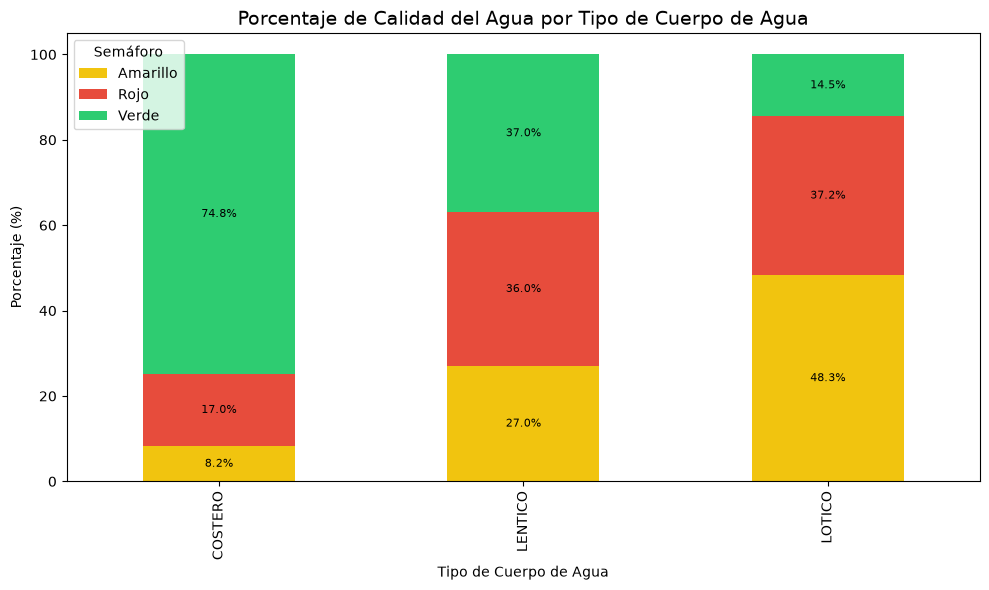

In [46]:
porcentajes = pd.crosstab(
    df['GRUPO'],
    df['SEMAFORO'],
    normalize='index'
) * 100

ax = porcentajes.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    color=[
        '#f1c40f',
        '#e74c3c',
        '#2ecc71'
    ]
)

plt.title(
    'Porcentaje de Calidad del Agua por Tipo de Cuerpo de Agua',
    fontsize=14
)

plt.xlabel('Tipo de Cuerpo de Agua')
plt.ylabel('Porcentaje (%)')

for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',
        label_type='center',
        fontsize=8
    )

plt.legend(title='Semáforo')

plt.tight_layout()
plt.show()

### Grafico 5 - Indicadores microbiológicos

Los indicadores microbiológicos son organismos utilizados para detectar contaminación fecal en cuerpos de agua.

**Coliformes fecales (COLI_FEC_NMP_100mL)**

Son bacterias presentes en los intestinos de humanos y animales de sangre caliente. Su presencia en el agua indica contaminación por materia fecal y posibles descargas de aguas residuales.

**E. Coli (E_COLI_NMP_100mL)**

Es un tipo específico de coliforme fecal y uno de los mejores indicadores de contaminación fecal reciente. Su detección suele asociarse con la presencia de excretas humanas o animales.

**Enterococos (ENTEROC_NMP_100mL)**

Son bacterias intestinales que sobreviven durante más tiempo en ambientes acuáticos, por lo que se utilizan para evaluar contaminación fecal persistente, especialmente en aguas recreativas.

-----------------------------

El indicador que muestra la relación más fuerte con el deterioro de la calidad del agua es E. Coli.

Mientras que en sitios verdes el promedio es de apenas 142 organismos por cada 100 mL, en sitios rojos supera los 227 mil organismos por cada 100 mL.

Esto representa un incremento cercano a 1 600 veces, convirtiéndolo en el mejor indicador microbiológico de contaminación dentro de este conjunto de datos.

----------------
El análisis microbiológico evidencia una relación directa entre la contaminación fecal y la calidad del agua. Los sitios clasificados en semáforo rojo presentan concentraciones extremadamente superiores de coliformes fecales, E. Coli y enterococos respecto a los sitios verdes. Debido a la gran diferencia de magnitudes entre los valores observados, se utilizó una escala logarítmica en el eje vertical para facilitar la visualización y comparación de los datos. Los resultados muestran que E. Coli es el indicador microbiológico más asociado con el deterioro de la calidad del agua, alcanzando concentraciones aproximadamente 16000 veces mayores en los sitios clasificados como rojos.

          COLI_FEC_NMP_100mL  E_COLI_NMP_100mL  ENTEROC_NMP_100mL
SEMAFORO                                                         
Amarillo            12209.32           7553.64              74.22
Rojo               260128.08         227198.69            6324.80
Verde                 315.69            142.27              44.48


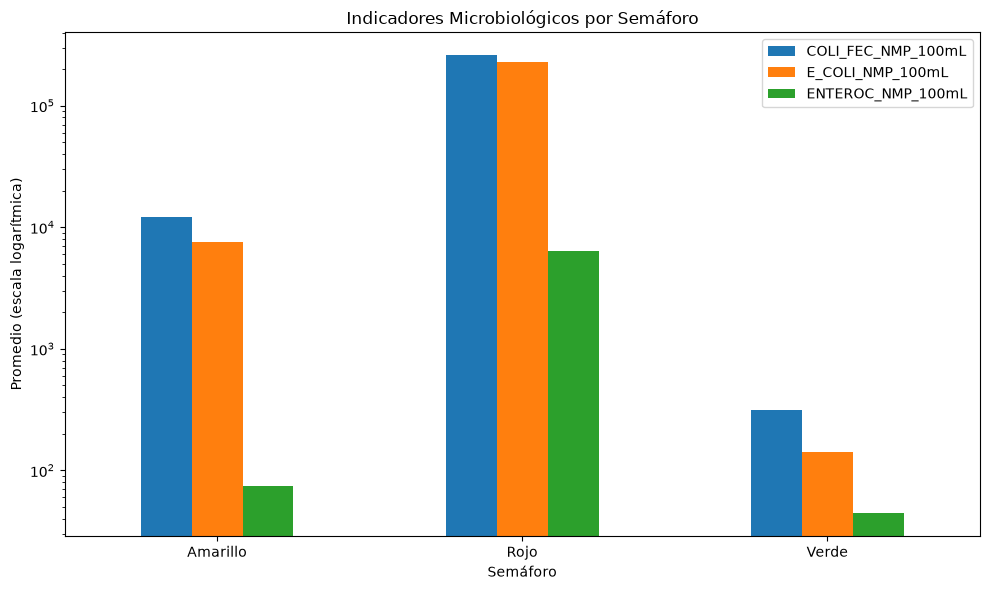

In [47]:
variables_micro = [
    'COLI_FEC_NMP_100mL',
    'E_COLI_NMP_100mL',
    'ENTEROC_NMP_100mL'
]

promedios_micro = (
    df.groupby('SEMAFORO')[variables_micro]
      .mean()
      .round(2)
)

print(promedios_micro)
promedios_micro.plot(
    kind='bar',
    figsize=(10,6)
)

plt.yscale('log')

plt.title('Indicadores Microbiológicos por Semáforo')
plt.xlabel('Semáforo')
plt.ylabel('Promedio (escala logarítmica)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()